In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Importing Required library
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing with NLTK & spaCy


## Task 1: Load and Explore the Dataset

**Objective:** Understand the data structure and perform basic Exploratory Data Analysis (EDA).

In this task, we will create a read a given dataset and explore it.

1. Check first 5 rows
2. Analyse Class distribution
3. Analyse Text Length


In [3]:
import pandas as pd

# 1.1 Read dataset
df = pd.read_csv('emo_text.csv')

# 1.2 Basic Exploration
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 rows:")
display(df.head())

Dataset Shape: (17289, 2)

First 5 rows:


,sentiment,content
0,negative,Layin n bed with a headache ughhhh...waitin o...
1,negative,Funeral ceremony...gloomy friday...
2,neutral,@dannycastillo We want to trade with someone w...
3,negative,"I should be sleep, but im not! thinking about ..."
4,negative,@charviray Charlene my love. I miss you


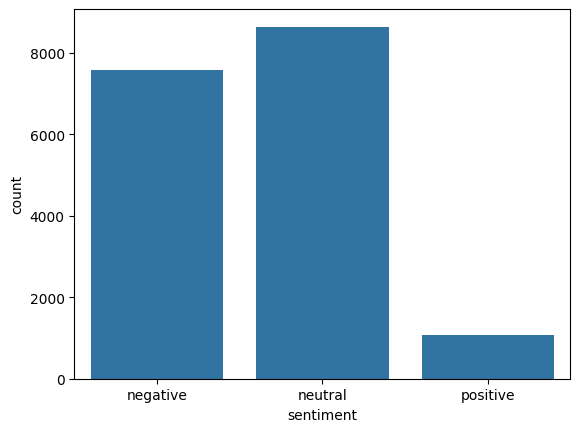

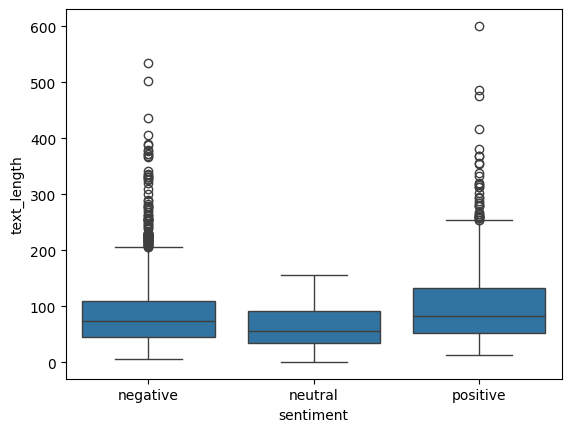

In [7]:
# 1.3 Analyse Class distribution
sns.countplot(x=df['sentiment'])
plt.show()

# 1.4 Analyse Text Length
df['text_length'] = df['content'].apply(len)
sns.boxplot(x=df['sentiment'],y=df['text_length'])
plt.show()

which shows there's some bias in the class distribution so we have to apply class resampling methods
From the boxplot we can say if the text length is short it has high probabitility of having neutral sentiment

## Task 2: Text Pre-processing with NLTK

**Objective:** Learn the "classic" way of cleaning text using the Natural Language Toolkit (NLTK). We will cover Tokenization, Stopword Removal, and Stemming.

Write a python function `preprocess_nltk(text)` that does the following using `NLTK Library`:

1. Normalising the text (Lowercasing)
2. Tokenization (Splitting text into words)
3. Removing Punctuation and Stopwords
4. Stemming (Reducing words to their root form, e.g., "running" -> "run")

and return cleaned text

In [30]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
import string

# Download necessary NLTK data
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

# Initialize Stemmer and Stopwords
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_nltk(text):
  text = text.lower()
  tokens = word_tokenize(text)

  # other method
  # MwETokenizer -> NLTK
  #[(hello,there)] -> [hello_there]
  # bigramfinder -> NLTK
  # BM

  cleaned_tokens = [word for word in tokens if word not in stop_words and word not in string.punctuation]
  stemmed_tokens = [stemmer.stem(word) for word in cleaned_tokens]
  return " ".join(stemmed_tokens)

df['NLTK_Cleaned'] = df['content'].apply(preprocess_nltk)

# calling function
print("Original vs NLTK Processed:")
display(df[['content', 'NLTK_Cleaned']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original vs NLTK Processed:


,content,NLTK_Cleaned
0,Layin n bed with a headache ughhhh...waitin o...,layin n bed headach ughhhh ... waitin call ...
1,Funeral ceremony...gloomy friday...,funer ceremoni ... gloomi friday ...
2,@dannycastillo We want to trade with someone w...,dannycastillo want trade someon houston ticket...
3,"I should be sleep, but im not! thinking about ...",sleep im think old friend want 's marri damn a...
4,@charviray Charlene my love. I miss you,charviray charlen love miss


## Task 3: Advanced Pre-processing with spaCy

**Objective:** Use spaCy's industrial-strength pipeline for efficient processing, focusing on Lemmatization.

wrtie a python function `preprocess_spacy(text` that does the follwoing thing using `spacy`:

1. Create a spaCy Doc object
2. Lemmatization and stopword removal

and return cleaned text

In [32]:
import spacy

# Load the small English model
nlp = spacy.load("en_core_web_sm")

def preprocess_spacy(text):
  # Create a spaCy Doc object
  doc = nlp(text)
  # Lemmatization and stopword removal
  cleaned_tokens = [token.lemma_ for token in doc if not token.is_stop]
  return " ".join(cleaned_tokens)

# calling fucntion
df['Spacy_Cleaned'] = df['content'].apply(preprocess_spacy)

print("NLTK (Stemmed) vs spaCy (Lemmatized):")
display(df[['NLTK_Cleaned', 'Spacy_Cleaned']].head())

NLTK (Stemmed) vs spaCy (Lemmatized):


,NLTK_Cleaned,Spacy_Cleaned
0,layin n bed headach ughhhh ... waitin call ...,Layin n bed headache ughhhh ... waitin ...
1,funer ceremoni ... gloomi friday ...,funeral ceremony ... gloomy friday ...
2,dannycastillo want trade someon houston ticket...,"@dannycastillo want trade Houston ticket , ."
3,sleep im think old friend want 's marri damn a...,"sleep , m ! think old friend want . marry . da..."
4,charviray charlen love miss,@charviray charlene love . miss


## Task 4: Feature Engineering (Bag of Words & TF-IDF)

**Objective:** Machines cannot understand text. We must convert text into numbers (vectors).

### 4.1 Count Vectorizer (Bag of Words)
This method counts how many times each word appears in a document.

In [33]:
from sklearn.feature_extraction.text import CountVectorizer

# Initialize
count_vect = CountVectorizer()

# Fit and Transform the spaCy cleaned text
X_counts = count_vect.fit_transform(df['Spacy_Cleaned'])

# Convert to array to visualize
count_array = X_counts.toarray()
df_counts = pd.DataFrame(data=count_array, columns=count_vect.get_feature_names_out())

print("Count Vector Representation (Bag of Words):")
display(df_counts.head())

Count Vector Representation (Bag of Words):


,00,000,00am,02,023,0255,02mxjj,03,04,05,...,½u,½ulein,½ureo,½ve,½who,½why,½whyyy,½y,½z,½ï
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### 4.2 TF-IDF (Term Frequency - Inverse Document Frequency)
This method highlights words that are important to a specific document but rare across the corpus (filtering out common words like "the", "is", etc., even if stopwords didn't catch them).

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize
tfidf_vect = TfidfVectorizer()

# Fit and Transform
X_tfidf = tfidf_vect.fit_transform(df['Spacy_Cleaned'])

# Convert to array to visualize
tfidf_array = X_tfidf.toarray()
df_tfidf = pd.DataFrame(data=tfidf_array, columns=tfidf_vect.get_feature_names_out())

print("TF-IDF Vector Representation:")
display(df_tfidf.head())

TF-IDF Vector Representation:


,00,000,00am,02,023,0255,02mxjj,03,04,05,...,½u,½ulein,½ureo,½ve,½who,½why,½whyyy,½y,½z,½ï
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Task 5: Sentiment Analysis Model

**Objective:** Build a Machine Learning classifier to predict sentiment based on our text features.

Write a python code that builds `MultinomiaNB` model that is trained on TF-IDF values and sentiment.

In [37]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, confusion_matrix

# Prepare features (X) and target (y)
X = X_tfidf  # Our TF-IDF features
y = df['sentiment']  # Our sentiment labels

# 1. Split Data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Train Model (Naive Bayes is excellent for text)
model = MultinomialNB()
model.fit(X_train, y_train)

# 3. Predict
y_pred = model.predict(X_test)

# 4. Evaluate
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

    negative       0.60      0.72      0.66      1496
     neutral       0.74      0.70      0.72      1753
    positive       1.00      0.05      0.09       209

    accuracy                           0.67      3458
   macro avg       0.78      0.49      0.49      3458
weighted avg       0.70      0.67      0.65      3458



## Task 6: Interactive Prediction

**Objective:** Test the model with new, unseen user input.


Write python function `predict_sentiment(text)` that predict the sentiment of the given text by performing the following:
1. Preprocess using our defined spaCy function
2. Vectorize using the fitted TF-IDF object
3. Prediction

and returns the predicted sentiment.

In [38]:
def predict_sentiment(text):
    # 1. Preprocess using our defined spaCy function
    cleaned_text = preprocess_spacy(text)
    # 2. Vectorize using the fitted TF-IDF object
    # TfidfVectorizer expects an iterable, so we pass a list with one element
    text_vectorized = tfidf_vect.transform([cleaned_text])
    # 3. Prediction
    prediction = model.predict(text_vectorized)
    return prediction[0]

# Test with your own strings
new_review = "The product was okay but the delivery was very slow."
print(f"Review: '{new_review}'")
print(f"Predicted Sentiment: {predict_sentiment(new_review)}")

new_review_2 = "I absolutely loved it! Best day ever."
print(f"Review: '{new_review_2}'")
print(f"Predicted Sentiment: {predict_sentiment(new_review_2)}")

Review: 'The product was okay but the delivery was very slow.'
Predicted Sentiment: neutral
Review: 'I absolutely loved it! Best day ever.'
Predicted Sentiment: neutral
